01_data_exploration.ipynb

1. Dataset Overview
2. Split Statistics
3. Class Distribution
4. Bounding Box Analysis
5. Missing Labels
6. Corrupt Images
7. Duplicate Detection
8. Visual Annotation Inspection
9. Findings & Conclusions

In [28]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Dataset Overview


In [23]:
DATASET_PATH = Path(r"C:\Users\aa683\Desktop\ppe_detection\data\processed")
print("Dataset:", DATASET_PATH)

for split in ["train", "valid", "test"]:
    split_path = DATASET_PATH / split

    print(f"\n--- {split.upper()} ---")

    if split_path.exists():
        print(list(split_path.iterdir()))
    else:
        print("Split does not exist")

Dataset: C:\Users\aa683\Desktop\ppe_detection\data\processed

--- TRAIN ---
[WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/train/images'), WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/train/labels')]

--- VALID ---
[WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/valid/images'), WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/valid/labels')]

--- TEST ---
[WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/test/images'), WindowsPath('C:/Users/aa683/Desktop/ppe_detection/data/processed/test/labels')]


# Split Statistics

In [ ]:

DATASET_PATH = Path(r"C:\Users\aa683\Desktop\ppe_detection\data\processed")

splits = ["train", "valid", "test"]

for split in splits:
    images_path = DATASET_PATH / split / "images"
    labels_path = DATASET_PATH / split / "labels"

    image_files = list(images_path.glob("*"))
    label_files = list(labels_path.glob("*.txt"))

    print(f"\n{split.upper()}")
    print(f"Images : {len(image_files)}")
    print(f"Labels : {len(label_files)}")


TRAIN
Images : 2605
Labels : 2605

VALID
Images : 114
Labels : 114

TEST
Images : 82
Labels : 82


# Class Distribution

In [ ]:
from pathlib import Path
from collections import Counter

# مكان الداتا
DATASET_PATH = Path(
    r"C:\Users\aa683\Desktop\ppe_detection\data\processed"
)

# أسماء الـclasses
CLASS_NAMES = {
    0: "Hardhat",
    1: "Mask",
    2: "NO-Hardhat",
    3: "NO-Mask",
    4: "NO-Safety Vest",
    5: "Person",
    6: "Safety Cone",
    7: "Safety Vest",
    8: "machinery",
    9: "vehicle"
}

# العداد
counts = Counter()

# train + valid + test
for split in ["train", "valid", "test"]:

    labels_folder = DATASET_PATH / split / "labels"

    # كل ملفات txt
    for file in labels_folder.glob("*.txt"):

        # افتح الملف
        with open(file, "r") as f:

            # اقرأ كل annotation
            for line in f:

                if line.strip():

                    # أول رقم هو class_id
                    class_id = int(line.split()[0])

                    # زود العداد
                    counts[class_id] += 1


# اطبع النتيجة
print("Class Distribution")
print("------------------")

for class_id in sorted(counts):

    print(
        CLASS_NAMES[class_id],
        ":", 
        counts[class_id]
    )

Class Distribution
------------------
Hardhat : 3334
Mask : 1700
NO-Hardhat : 2427
NO-Mask : 3250
NO-Safety Vest : 4158
Person : 9872
Safety Cone : 3502
Safety Vest : 3135
machinery : 5346
vehicle : 1628


# Bounding Box Analysis

In [44]:
import pandas as pd

records = []

for split in ["train", "valid", "test"]:

    labels_path = DATASET_PATH / split / "labels"

    for label_file in labels_path.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                records.append({
                    "split": split,
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height
                })

df = pd.DataFrame(records)

df.head()

,split,class_id,class_name,x_center,y_center,width,height
0,train,0,Hardhat,0.077542,0.393750,0.090970,0.059375
1,train,0,Hardhat,0.016406,0.413281,0.032813,0.120313
2,train,3,NO-Mask,0.046823,0.436719,0.039353,0.050000
3,train,3,NO-Mask,0.091241,0.456250,0.050200,0.034375
4,train,5,Person,0.163281,0.420312,0.326562,0.178125


# Missing Labels

In [48]:
for split in ["train", "valid", "test"]:

    images_path = DATASET_PATH / split / "images"
    labels_path = DATASET_PATH / split / "labels"

    missing_labels = []

    for image in images_path.iterdir():

        if image.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        label = labels_path / f"{image.stem}.txt"

        if not label.exists():
            missing_labels.append(image.name)

    print(f"\n{split}")
    print("Images without labels:", len(missing_labels))

    if missing_labels:
        print(missing_labels[:10])


train
Images without labels: 0

valid
Images without labels: 0

test
Images without labels: 0


# Corrupt Images

In [46]:
from PIL import Image

for split in ["train", "valid", "test"]:

    images_path = DATASET_PATH / split / "images"

    corrupt_images = []

    for image_path in images_path.iterdir():

        if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupt_images.append(image_path.name)

    print(f"{split}: {len(corrupt_images)} corrupt images")

    if corrupt_images:
        print(corrupt_images[:10])

train: 0 corrupt images
valid: 0 corrupt images
test: 0 corrupt images


# Target Classes

In [53]:
TARGET_CLASSES = [
    "Person",
    "Hardhat",
    "Safety Vest"
]

target_df = df[df["class_name"].isin(TARGET_CLASSES)].copy()

print(target_df["class_name"].value_counts())

class_name
Person         9872
Hardhat        3334
Safety Vest    3135
Name: count, dtype: int64


In [ ]:
target_df["box_area"] = (
    
    target_df["width"] * target_df["height"]
)

print(
    target_df
    .groupby("class_name")["box_area"]
    .describe()
)

              count      mean       std       min       25%       50%  \
class_name                                                              
Hardhat      3334.0  0.011425  0.029948  0.000010  0.000668  0.002003   
Person       9872.0  0.095030  0.102138  0.000029  0.011578  0.061680   
Safety Vest  3135.0  0.029379  0.046766  0.000029  0.001865  0.009582   

                  75%       max  
class_name                       
Hardhat      0.008530  0.383203  
Person       0.149642  0.990625  
Safety Vest  0.036312  0.377930  


# Visual Plots

C:\Users\aa683\AppData\Local\Temp\ipykernel_36332\2513461218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=target_df , x = "class_name" , ax = axes[0] , palette="Set2")
C:\Users\aa683\AppData\Local\Temp\ipykernel_36332\2513461218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=target_df , x = "class_name" , y = "box_area" , ax = axes[1] , palette="Set2")


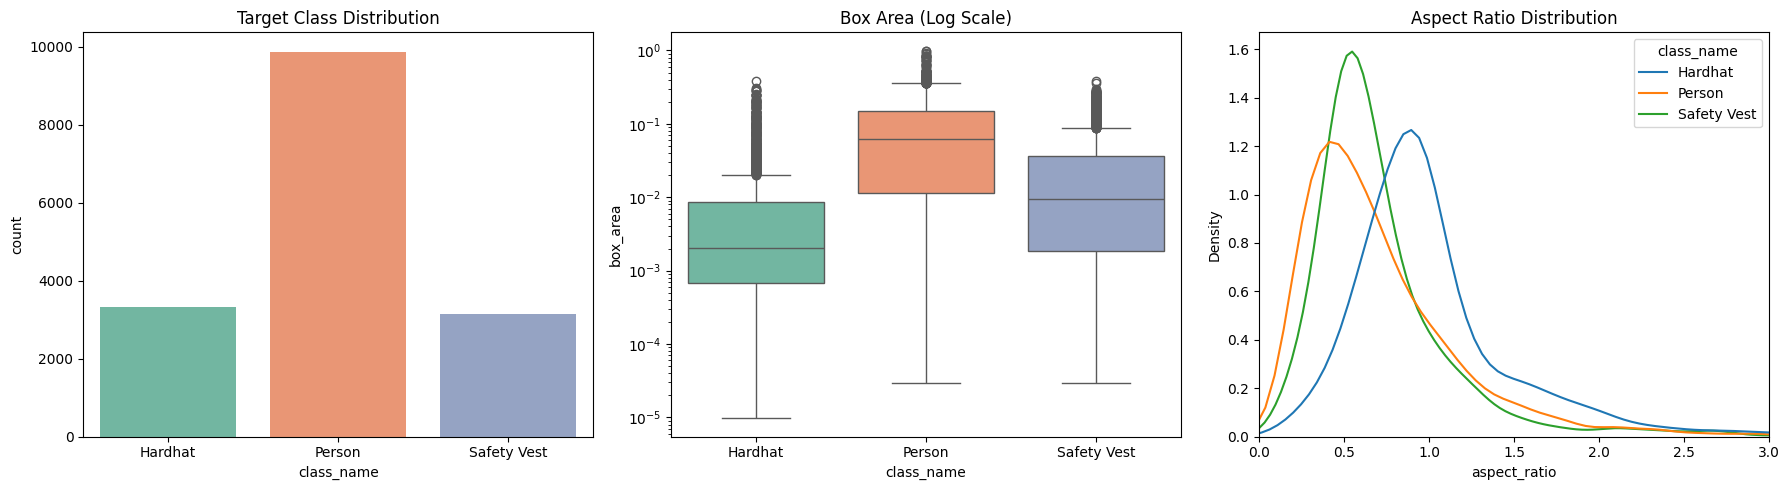

In [86]:
fig , axes = plt.subplots(1 , 3 , figsize=( 18 , 5 ))

sns.countplot(data=target_df , x = "class_name" , ax = axes[0] , palette="Set2")
axes[0].set_title("Target Class Distribution")


sns.boxplot(data=target_df , x = "class_name" , y = "box_area" , ax = axes[1] , palette="Set2")
axes[1].set_yscale("log")
axes[1].set_title("Box Area (Log Scale)")



target_df["aspect_ratio"] = target_df["width"] / target_df["height"]
sns.kdeplot(data=target_df, x="aspect_ratio", hue="class_name", ax=axes[2], common_norm=False)
axes[2].set_xlim(0, 3)
axes[2].set_title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

# Duplicate Detection

In [87]:
import hashlib

def get_image_md5(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = {get_image_md5(p): p.name for p in (DATASET_PATH / "train" / "images").glob("*.*")}
valid_hashes = {get_image_md5(p): p.name for p in (DATASET_PATH / "valid" / "images").glob("*.*")}

overlap = set(train_hashes.keys()) & set(valid_hashes.keys())
print(f"Exact Duplicate Images between Train and Valid: {len(overlap)}")


Exact Duplicate Images between Train and Valid: 0


# Visual Annotation Inspection Grid

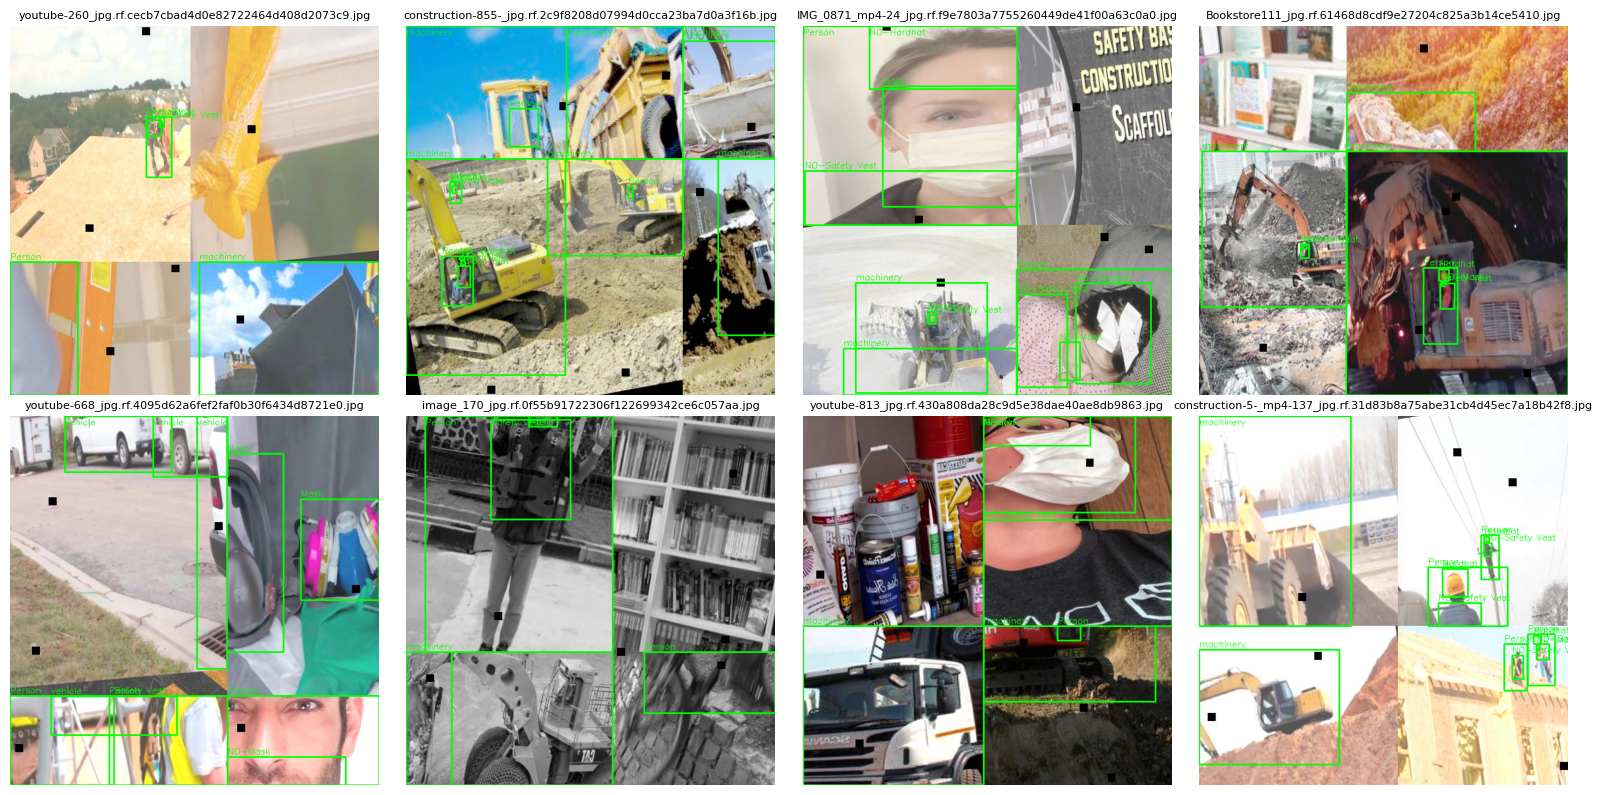

In [92]:
import cv2
import matplotlib.pyplot as plt
import random

def draw_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    h, w, _ = img.shape

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                cid, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                
                label = CLASS_NAMES.get(int(cid), str(int(cid)))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, label, (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# اختيار 8 صور عشوائية وعرضها
images = list((DATASET_PATH / "train/images").glob("*.jpg"))
samples = random.sample(images, min(8, len(images)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for img_p, ax in zip(samples, axes.flat):
    lbl_p = DATASET_PATH / "train/labels" / f"{img_p.stem}.txt"
    ax.imshow(draw_boxes(img_p, lbl_p))
    ax.set_title(img_p.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 📋 Dataset Weaknesses & Findings:

* **Severe Small Object Challenge**: Hardhats occupy extremely small bounding box areas (< 0.2% of the image size), requiring a training resolution of at least `imgsz=640`, along with potential P2 detection layers or small-object detection heads if necessary.

* **Split Imbalance**: The training split accounts for ~93% of the dataset, while validation and test sets account for only 4% and 3%, respectively. A more balanced split is required to ensure sufficient representation of challenging edge cases in the validation set.

* **Class Strategy Decision**: We will adopt **Approach B** (training the detector exclusively on positive classes: `Person`, `Hardhat`, `Safety Vest`) and ignore negative label classes (`NO-*`) during object detection to maximize recall, delegating violation inferences directly to the downstream business logic engine.